In [22]:
import sys  
import numpy as np
sys.path.insert(1, '/Users/cosmo/Dropbox/University/Year 3/Individual Project/code/')

import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2
from src import BoidSimulator ,BoidVisualizer ,PropertyAnalysis ,SimSaverLoader ,SimParams ,KernelReadout, FlatReadout

/Users/cosmo/Dropbox/University/Year 3/Individual Project/code/src/PropertyAnalysis.py:61: SyntaxWarning: invalid escape sequence '\l'
  $c_{xx} = \langle x_i(t) * x_j(t)\rangle$   latex version


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Fig 1

## a
the x-coordinate of the Lorenz system 0.5 units in the future (black). The prediction by the particle position based reservoir is shown in red.

In [2]:
run_path = '/Users/cosmo/Dropbox/University/Year 3/Individual Project/code/tests/donut'
data = SimSaverLoader.find_npzs(run_path)

Loaded 2 run(s)


In [ ]:
visualiser = BoidVisualizer([data[0]])
visualiser.get_frames(max_columns=5, frame_indexes=range(900,1000,10),trails=10)
plt.show()

## b
Consistency profile of the reservoir truncated to the largest 100 components
$\Theta$

In [2]:
run_path = '/Users/cosmo/Dropbox/University/Year 3/Individual Project/code/tests/super_long'
datas = SimSaverLoader.find_npzs(run_path)
fr = FlatReadout(datas[0],datas[1])

v1= fr.get_reservoir_state_vectorised(datas[0])
v2= fr.get_reservoir_state_vectorised(datas[1])

pa = PropertyAnalysis([v1,v2])


Loaded 2 run(s)


-0.46344904410256127


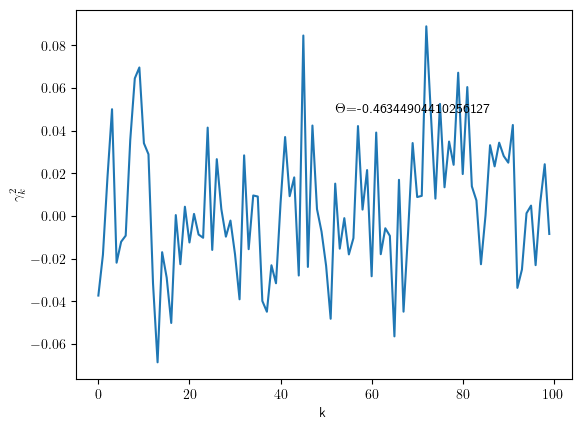

In [3]:
print(pa.calc_consistent_capacity(pa.sv_norm[0],pa.sv_norm[1]))

ccx = pa.calc_x_covariance_matrix(pa.sv_norm[0],pa.sv_norm[1])
ax = pa.plot_consistency_profile(ccx)
plt.show()

# Fig 2

In [5]:
run_path = '/Users/cosmo/Dropbox/University/Year 3/Individual Project/code/tests/super_long'
datas = SimSaverLoader.find_npzs(run_path)
fr = FlatReadout(datas[0],datas[1])
fr.make_prediction(0.1)

Loaded 2 run(s)


array([ 0.28166074, -0.37484123, -1.30112045, ..., -0.0748757 ,
        0.13564506, -0.5606011 ], shape=(9999,))

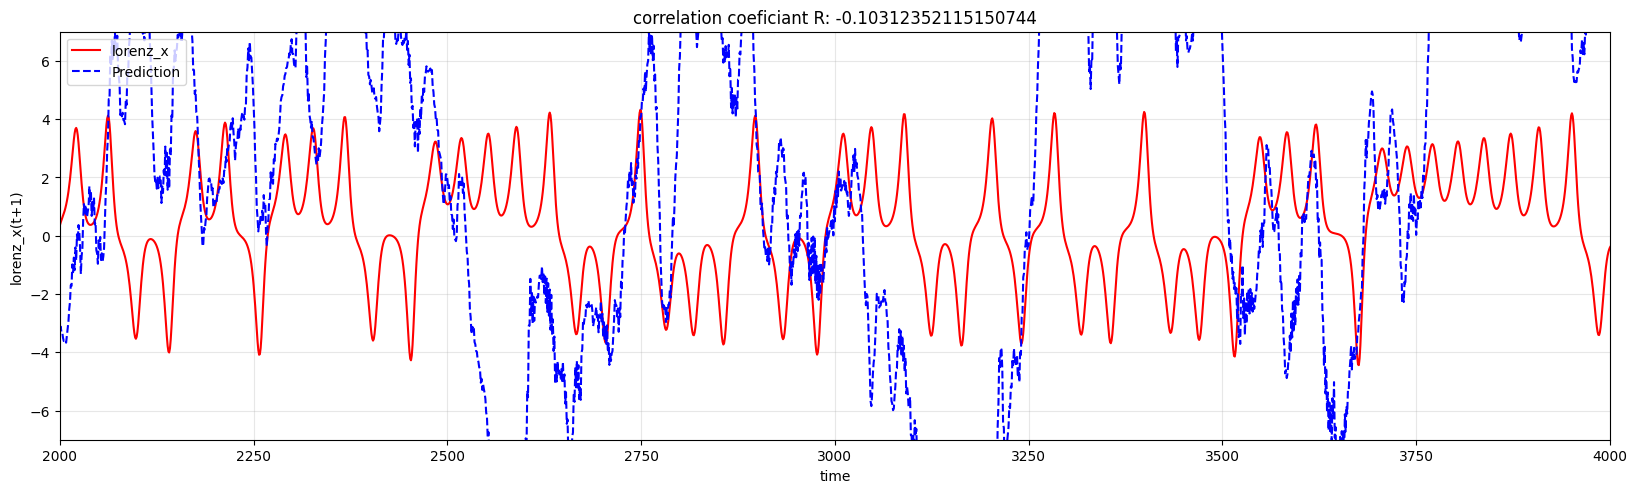

In [7]:
plot = fr.get_plot(fr.prediction,[2000,4000])
plot.set_ybound(-7,7)
plt.show()

# Fig 5

In [23]:
run_path = '/Users/cosmo/Dropbox/University/Year 3/Individual Project/code/tests/super_long'
datas = SimSaverLoader.find_npzs(run_path)

Loaded 2 run(s)


In [69]:
kr = KernelReadout(200,datas[0],datas[1])
v1 = kr.get_reservoir_state_vectorised(datas[0])
v2 = kr.get_reservoir_state_vectorised(datas[1])

pa = PropertyAnalysis([v1,v2])
cxx = pa.calc_x_covariance_matrix(*pa.sv_norm)

prediction,corr_coef = kr.ridge_prediction(v1,v2)

Vectorised: 100%|██████████| 10/10 [00:10<00:00,  1.06s/it]


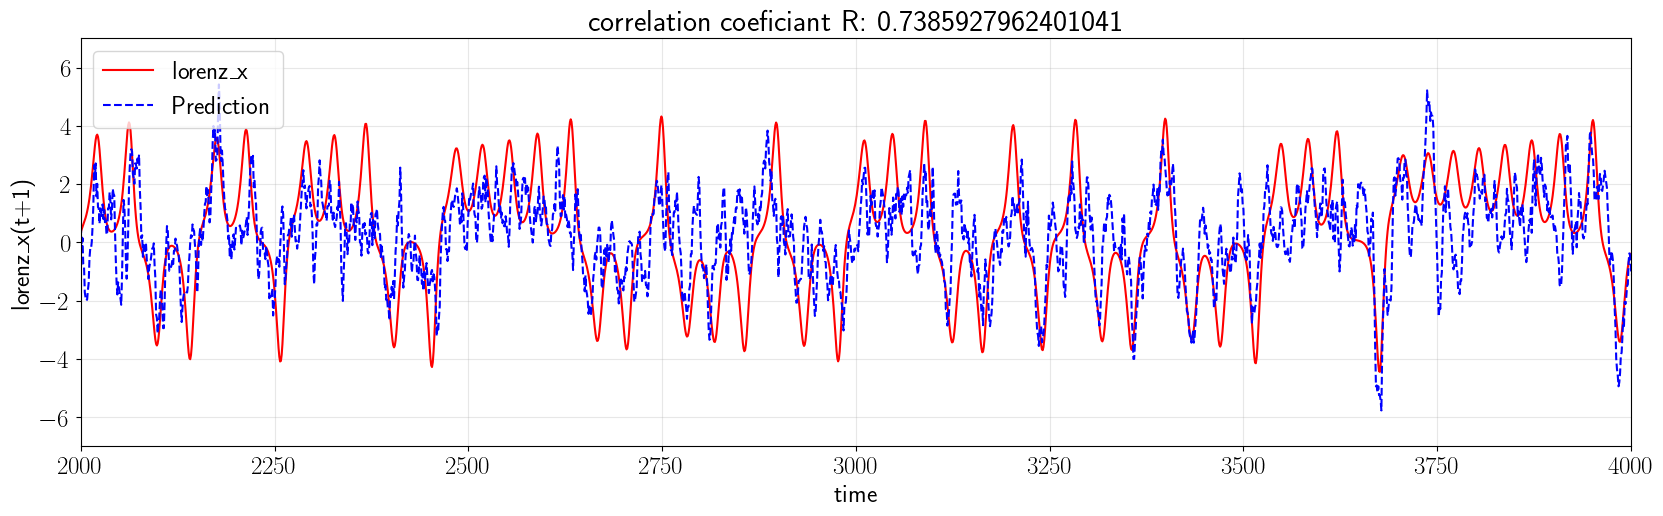

<Axes: xlabel='$k$', ylabel='$\\gamma^{2}_{k}$'>

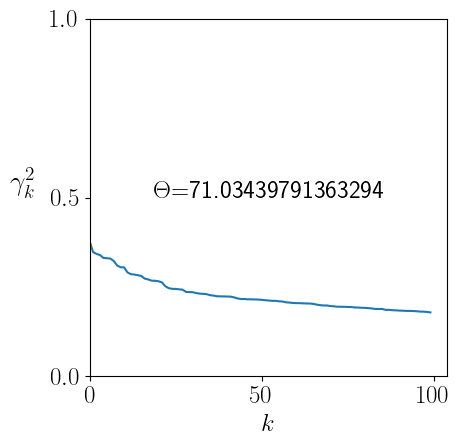

In [70]:
plot = kr.get_plot(prediction,corr_coef,[2000,4000])
plot.set_ybound(-7,7)
plt.show()

pa.plot_consistency_profile(cxx,dpi=100)
